LIBRERIE PRINCIPALI: OPENCV, PIL, SCIKIT-IMAGE

In Pytohn abbiamo diverse cassette degli attrezzi per gestire le immagini.

- Panoramica dell'ecosistema: Oper CV, Pillow, scikit-image
- Allestimento e verifica dell'ambiente


Perchè esistono così tante librerie?
Python è diventato il re della computer visione.
Python domina la Computer Vision non per una singola persone, ma per la sinergia tra struenti diversi.
Alcune librerie sono nate per la velocità, altre per la semplicità (come macchina)
Durante l'addestramento il tempo speso a caricare le immagini diventa un collo di bottiglia.

Le 3 librerie: 1) OpenCV, 2) Pillow, 3)scikit-image, lavorano con le immagini, ma non sono equivalenti.
Non ha senso stabili quale sia la migliore, 

- Open CV: è lo standard per il tempo reale, alte prestazioni.  Nata nei laboratori intel, è la scelta obbligata quando si processano flussi video live o si lavora in ambito automotive
- Pillow (PIL): ideale per operazioni di base, gestione metadati e manipolazione rapida di formtati. Tratta l'immagine com eun oggetto alto, facile da manipolare da noi umani
- Pillow (PIL): ideale per operazioni di base.
- Scikit-image: focalizzata sull'analisti, ofre algoritmi

*** OPENCV ***

OpenCV significa Open Source Computer Visione Library
E' la libreria più completa delle tre, per costruire vere applicazioni di Computer Vision.
Comprendere operazioni sull'immagine, trasformazioni geometriche, filtri, ananlisi, 

Lettura immagine: 

si installa python -m pip install opencv-python, ma si imoprta come cv2

Lettura immagine:
import cv2
immagine = cv2.imread("foto.jpg")
if immagine is None:
    raise FileNotFoundError("Immagine non trovata o non leggibile")
print(type(immagine))
print(immagine.shape)
print(immagine.dtype)

Open CV rappresenta normalmente le immagini Python come array NumPy. dimensione e tipi dei dati sono informazioni essenziali, molti errori derivano proprio da form aè dtype non correnti.
Una immagine normale viene, normalmente rappresentata come RGB (roso, verde, blu).
Opern CV, per impostazione predefinita lavora con  BGR

Lettura immagine:
immagine_bgr = cv2.imread("foto.jpg")

immagine_rgb = cv2.cvtColor(
    immagine_bgr,
    cv2.COLOR_BGR2RGB
)

Conversione in scala di grigi:
grigia = cv2.cvtColor(
    immagine_bgr,
    cv2.COLOR_BGR2GRAY
)

print(grigia.shape)

Il risultato non avrà più 3 canali, ogni pixel contiene un solo valore di luminosità

Ridimensionamento immagine:
ridimensionata = cv2.resize(
    immagine_bgr,
    (224, 224)
)
Attenzione all'ordine (larghezza, altezza)

Sfumature e riduzione rumore:
sfocata = cv2.GaussianBlur(
    immagine_bgr,
    (5, 5),
    0
)
il filtro gaussiano riduce variazioni locali e rumore, ma elimina anche una parte di dettagli

Rilevamento bordi:
grigia = cv2.cvtColor(
    immagine_bgr,
    cv2.COLOR_BGR2GRAY
)

bordi = cv2.Canny(
    grigia,
    100,
    200
)
Il risultato evidenzai le zone dove la luminosità cambia rapidamente.

OpenCV è la scelta più naturale quando devi lavorare con una webcam:
import cv2

camera = cv2.VideoCapture(0)

if not camera.isOpened():
    raise RuntimeError("Impossibile aprire la webcam")

while True:
    acquisita, frame = camera.read()

    if not acquisita:
        break

    cv2.imshow("Webcam", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

camera.release()
cv2.destroyAllWindows()

*** PILLOW ***

si installa: python -m pip install Pillow
ma si imorta from PIL import Image

Pillow è orientato soprattutto alla gestione del file immagine, apertura, salvataggio, conversione tra formati, ritaglio, rotazione, resize, filtri, trasformazioni, testo è composizione grafica. Supporta molti formati 

Apertura immagine:
from PIL import Image

immagine = Image.open("foto.jpg")

print(type(immagine))
print(immagine.format)
print(immagine.size)
print(immagine.mode)

Pillow tratta le immagini rester come rettangoli di pixel organizzati in una o più bande

conversione colore:
immagine_rgb = immagine.convert("RGB")
immagine_grigia = immagine.convert("L")

Ridimensionamento:
immagine_ridimensionata = immagine.resize((224, 224))

Ritaglio
ritaglio = immagine.crop((100, 50, 400, 300))

Rotazione
ruotata = immagine.rotate(30,expand=True)

salvataggio
immagine.save("risultato.png")

inserimento testo
from PIL import Image, ImageDraw
immagine = Image.open("foto.jpg").convert("RGB")
disegno = ImageDraw.Draw(immagine)
disegno.text(
    (20, 20),
    "Classe: rock",
    fill=(255, 0, 0)
)

immagine.save("foto_classificata.jpg")

*** Conversione da Pillow a NumPy ***

import numpy as np
from PIL import Image
immagine_pil = Image.open("foto.jpg").convert("RGB")
immagine_np = np.array(immagine_pil)
print(immagine_np.shape)

*** SCIKIT-IMAGE ***
scikit-image, importata come skimage, è una raccolta di algoritmi per elaborazione delle immagini e Computer Vision, costruita intorno a NumPy e all'ecosistema scientifico di Python
Le immagini sono rappresentare direttamente come array NumPy

Si installa: python -m pip install scikit-image

Lettura immagine
from skimage import io
immagine = io.imread("foto.jpg")
print(type(immagine))
print(immagine.shape)
print(immagine.dtype)

Conversione scala grigi:
from skimage import color
grigia = color.rgb2gray(immagine)
print(grigia.shape)
print(grigia.dtype)
print(grigia.min(), grigia.max())

rimozione piccolo oggetti
from skimage import morphology
maschera_pulita = morphology.remove_small_objects(
    maschera,
    min_size=100
)

etichettatura oggetti:
from skimage import measure
etichette = measure.label(maschera_pulita)
numero_oggetti = etichette.max()
print("Oggetti trovati:", numero_oggetti)

misurazione regioni:
regioni = measure.regionprops(etichette)

for regione in regioni:
    print(
        "Area:", regione.area,
        "Centro:", regione.centroid,
        "Rettangolo:", regione.bbox
    )


PER RAGIONI STORICHE OPEN-CV INVERTE I CANALI UTILIZZA QUINDI BGR MENTRE MATPLOTLIB E PIL SI ASPETTANO RGB

Caricata con PIL: <class 'PIL.JpegImagePlugin.JpegImageFile'> | Formato: JPEG
Convertita in NumPy: (800, 1200, 3) | Dtype: uint8
Immagine salvata correttamente utilizzando Keras 3 utilities.


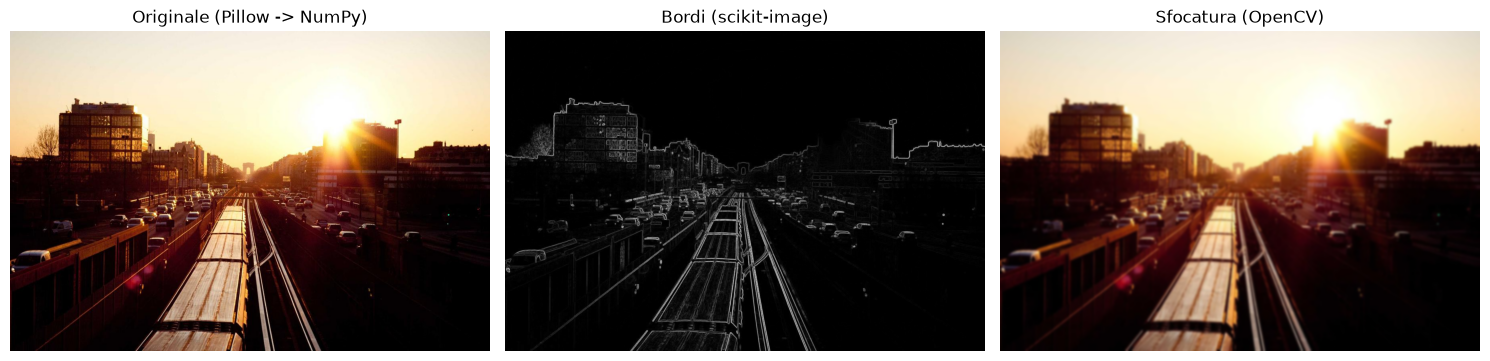

In [3]:
import os

# --- CONFIGURAZIONE BACKEND 2026 ---
# Keras 3 permette di scegliere il motore computazionale. 
# Scegliamo PyTorch per la sua flessibilità nel Deep Learning moderno.
os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import cv2  # OpenCV: Il motore per il tempo reale
from PIL import Image  # Pillow: Lo standard per la gestione file e metadati
from skimage import filters, color, util  # scikit-image: Analisi scientifica
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import keras # Utilizzato qui per utilities di pre-processing e salvataggio coerente

def workshop_librerie_immagini():
    """
    Dimostrazione dell'interoperabilità tra librerie.
    Concetto Teorico: L'Immagine come 'Dato Universale' (NumPy ndarray).
    """
    
    # 1. CARICAMENTO CON PILLOW (PIL)
    # Teoria: Pillow è eccellente per il caricamento iniziale e la gestione dei formati web.
    url = "https://picsum.photos/1200/800"
    response = requests.get(url)
    # Carichiamo come oggetto Image di Pillow (formato RGB di default)
    img_pil = Image.open(BytesIO(response.content))
    print(f"Caricata con PIL: {type(img_pil)} | Formato: {img_pil.format}")

    # 2. CONVERSIONE IN NUMPY (Il ponte)
    # Teoria: Le reti neurali leggono array, non oggetti. La conversione è il primo passo del pre-processing.
    img_array = np.array(img_pil)
    print(f"Convertita in NumPy: {img_array.shape} | Dtype: {img_array.dtype}")

    # 3. ELABORAZIONE CON SCIKIT-IMAGE
    # Teoria: scikit-image opera nativamente su array NumPy trattandoli come segnali scientifici.
    # Applichiamo un filtro di Sobel per trovare i bordi (Edge Detection).
    gray_sk = color.rgb2gray(img_array) # Converte in float64 [0, 1]
    edges = filters.sobel(gray_sk)

    # 4. ELABORAZIONE CON OPENCV (Problema BGR)
    # Teoria: OpenCV usa lo spazio colore BGR. Se passiamo un array RGB senza convertirlo, 
    # i canali Rosso e Blu verranno scambiati.
    # Eseguiamo un blur Gaussiano per ridurre il rumore ad alta frequenza.
    img_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    blurred_bgr = cv2.GaussianBlur(img_bgr, (15, 15), 0)
    # Torniamo in RGB per la visualizzazione corretta
    blurred_rgb = cv2.cvtColor(blurred_bgr, cv2.COLOR_BGR2RGB)

    # 5. SALVATAGGIO CON KERAS 3 (Best Practice 2026)
    # Teoria: Keras 3 standardizza il salvataggio per garantire che i dati siano 
    # pronti per l'input di un modello.
    keras.utils.save_img("output_elaborato.jpg", blurred_rgb)
    print("Immagine salvata correttamente utilizzando Keras 3 utilities.")

    # 6. VISUALIZZAZIONE SCIENTIFICA CON MATPLOTLIB
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.title("Originale (Pillow -> NumPy)")
    plt.imshow(img_array)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Bordi (scikit-image)")
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Sfocatura (OpenCV)")
    plt.imshow(blurred_rgb)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    workshop_librerie_immagini()